# Stage 4 — DistilBERT (Transformer)

## What is DistilBERT and why is it the most powerful model here?

In Stages 1–3 we built models from scratch. **DistilBERT is different** — it is a pre-trained model created by Hugging Face that has already read **billions of words** from the internet and books. It already understands English deeply before we even show it a single movie review.

What we do is called **fine-tuning**: we take this already-smart model and do a small amount of extra training on our IMDb dataset so it learns the specific task of sentiment classification. This is like hiring an expert who already knows how to read — you just train them on your specific job for a few days instead of teaching them to read from scratch.

### Why DistilBERT and not full BERT?
BERT is very large and slow. **DistilBERT** is a smaller, faster version that keeps ~97% of BERT's performance at 40% fewer parameters. It is much more practical for a GTX 1060.

### Key new concepts:
- **Tokenizer**: DistilBERT uses its own special tokenizer (WordPiece). We do NOT build a vocabulary ourselves — we use the pre-trained one.
- **[CLS] token**: Every input starts with a special `[CLS]` token. After the model processes the whole sequence, the `[CLS]` vector is used as a summary of the entire text — we feed that into our classifier.
- **Attention mask**: Tells the model which tokens are real words vs. padding zeros.
- **`transformers` library**: The Hugging Face library that gives us pre-trained models with one line of code.

### Baseline to beat: **89.51%** (Stage 1), then Stage 2 FNN, then Stage 3 LSTM

---

### Install transformers (run once)
If you have not installed the `transformers` library yet, uncomment and run the line below once, then comment it out again.

In [1]:
# Run this ONCE if transformers is not installed, then comment it out
# !pip install transformers

### Imports

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, auc
)

print("All imports successful.")

All imports successful.


### Set Device (GPU/CPU)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## Step 1 — Load Data

In [4]:
df = pd.read_csv('../data/IMDB Dataset.csv')
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Dataset shape: {df.shape}")
print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}")

Dataset shape: (50000, 2)
Sentiment distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64


---
## Step 2 — Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'].values,
    df['sentiment'].values,
    test_size=0.2,
    random_state=42
)

print(f"Train samples: {len(X_train):,}")
print(f"Test  samples: {len(X_test):,}")

Train samples: 40,000
Test  samples: 10,000


---
## Step 3 — Load the DistilBERT Tokenizer

The tokenizer converts raw text into the specific integer IDs that DistilBERT expects.
The first time you run this it will download the tokenizer files (~250 MB) from Hugging Face — this is normal.

`MAX_LEN = 128` means we truncate/pad every review to 128 tokens. DistilBERT supports up to 512, but 128 is a good balance between speed and accuracy for sentiment tasks and is much kinder to a 6 GB GPU.

In [6]:
MAX_LEN = 128

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print(f"Tokenizer vocabulary size: {tokenizer.vocab_size:,}")

# Quick demo: see what the tokenizer does to a sentence
sample = "This movie was absolutely fantastic!"
encoded = tokenizer(sample, max_length=MAX_LEN, truncation=True, padding='max_length')
print(f"\nSample sentence: {sample}")
print(f"Input IDs:       {encoded['input_ids'][:10]} ...")
print(f"Attention mask:  {encoded['attention_mask'][:10]} ...")
print("\n(1 in attention_mask = real token, 0 = padding)")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\manos\Desktop\PROJECTS\sentiment-analyzer\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\manos\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocabulary size: 30,522

Sample sentence: This movie was absolutely fantastic!
Input IDs:       [101, 2023, 3185, 2001, 7078, 10392, 999, 102, 0, 0] ...
Attention mask:  [1, 1, 1, 1, 1, 1, 1, 1, 0, 0] ...

(1 in attention_mask = real token, 0 = padding)


---
## Step 4 — Custom PyTorch Dataset

Our Dataset class tokenizes each review on the fly and returns three things the model needs:
- `input_ids`: the integer token IDs
- `attention_mask`: 1 for real tokens, 0 for padding
- `label`: 0 or 1

In [7]:
class IMDbBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        encoding = self.tokenizer(
            self.texts[i],
            max_length      = self.max_len,
            truncation      = True,
            padding         = 'max_length',
            return_tensors  = 'pt'   # return PyTorch tensors
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),       # (max_len,)
            'attention_mask': encoding['attention_mask'].squeeze(),  # (max_len,)
            'label':          torch.tensor(self.labels[i], dtype=torch.float)
        }


BATCH_SIZE = 16   # smaller than before — DistilBERT is much larger

train_dataset = IMDbBERTDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = IMDbBERTDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

Train batches: 2500
Test  batches: 625


---
## Step 5 — Define the Model

Our model has two parts:

1. **DistilBERT backbone**: The pre-trained model. It takes in token IDs and attention masks and outputs a vector for every token in the sequence. We only need the first vector (position 0), which corresponds to the special `[CLS]` token — DistilBERT is trained so that this vector summarizes the whole sentence.

2. **Classifier head**: A small neural network on top: Dropout → Linear(768→1) → Sigmoid. This is the part that actually learns to distinguish positive from negative sentiment.

The DistilBERT output at `[CLS]` has 768 dimensions — that is the hidden size of the model.

In [8]:
class SentimentDistilBERT(nn.Module):
    def __init__(self, dropout=0.3):
        super(SentimentDistilBERT, self).__init__()

        # Load the pre-trained DistilBERT backbone
        # First run: downloads ~250 MB of model weights from Hugging Face
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Classifier head on top
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, 1)   # 768 = DistilBERT hidden size
        self.sigmoid    = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        # Pass tokens through DistilBERT
        outputs = self.distilbert(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )
        # last_hidden_state shape: (batch_size, seq_len, 768)
        # Take only the [CLS] token (index 0) — it summarizes the whole review
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)

        out = self.dropout(cls_output)
        out = self.classifier(out)   # (batch_size, 1)
        out = self.sigmoid(out)
        return out.squeeze()         # (batch_size,)


model = SentimentDistilBERT(dropout=0.3).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     66,363,649
Trainable parameters: 66,363,649


---
## Step 6 — Loss, Optimizer & Scheduler

**Important**: We use a much smaller learning rate (`2e-5`) than in Stages 2 & 3.

Why? DistilBERT's weights are already very well tuned. If we use a large learning rate we will destroy all that pre-trained knowledge. A tiny LR lets the model gently adjust its weights to our task without forgetting what it already knows. This technique is called **fine-tuning**.

We also use a **linear warmup scheduler**: the LR starts at 0, rises to `2e-5` over the first few batches, then stays constant. This prevents a sudden large update at the very start of training from destabilizing the model.

In [9]:
from transformers import get_linear_schedule_with_warmup

EPOCHS     = 4       # BERT-style models converge fast — 3-4 epochs is standard
LR         = 2e-5    # very small — do not change this unless you know why

criterion  = nn.BCELoss()

optimizer  = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-2
)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = total_steps // 10   # warm up over first 10% of training

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps:         {warmup_steps:,}")

Total training steps: 10,000
Warmup steps:         1,000


---
## Step 7 — Early Stopping

In [10]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f"Restored best weights (val_loss={self.best_loss:.4f})")

early_stopping = EarlyStopping(patience=2)
print("EarlyStopping ready (patience=2 — we only train 4 epochs max).")

EarlyStopping ready (patience=2 — we only train 4 epochs max).


---
## Step 8 — Training & Evaluation Functions

Note the difference from Stage 2/3: we now pass **both** `input_ids` and `attention_mask` to the model — DistilBERT needs both.

In [11]:
def train_epoch(model, loader, criterion, optimizer, scheduler):
    """One training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss  = criterion(preds, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()   # update LR every batch (linear schedule)

        total_loss += loss.item() * len(labels)
        correct    += ((preds >= 0.5) == labels).sum().item()
        total      += len(labels)

    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    """Evaluate on loader. Returns (metrics_dict, y_pred, y_true, y_proba)."""
    model.eval()
    total_loss  = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            probs = model(input_ids, attention_mask)
            total_loss += criterion(probs, labels).item() * len(labels)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).cpu().numpy().astype(int))
            all_labels.extend(labels.cpu().numpy().astype(int))

    n = len(all_labels)
    metrics = {
        'loss':      total_loss / n,
        'accuracy':  accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall':    recall_score(all_labels, all_preds),
        'f1':        f1_score(all_labels, all_preds),
    }
    return metrics, all_preds, all_labels, all_probs

print("train_epoch and eval_epoch functions defined.")

train_epoch and eval_epoch functions defined.


---
## Step 9 — Training Loop

⚠️ **Important expectations for GTX 1060 6 GB**:
- Each epoch will take roughly **20–40 minutes** with `BATCH_SIZE=16` and `MAX_LEN=128`.
- You will likely get the best results in epoch 2 or 3 — DistilBERT converges quickly.
- If you get a CUDA out-of-memory error, reduce `BATCH_SIZE` to `8` in Step 4 and restart.
- Expected accuracy: **92–93%** — well above the 89.51% baseline.

In [12]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_f1':     []
}

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'='*60}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler)
    val_metrics, _, _, _  = eval_epoch(model, test_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])

    print(
        f"train_loss={train_loss:.4f}  "
        f"val_loss={val_metrics['loss']:.4f}  "
        f"val_acc={val_metrics['accuracy']:.4f}  "
        f"f1={val_metrics['f1']:.4f}"
    )

    if early_stopping.step(val_metrics['loss'], model):
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

early_stopping.restore(model)


Epoch 1/4
train_loss=0.3746  val_loss=0.3028  val_acc=0.8677  f1=0.8771

Epoch 2/4
train_loss=0.2349  val_loss=0.3368  val_acc=0.8845  f1=0.8886

Epoch 3/4
train_loss=0.1446  val_loss=0.4229  val_acc=0.8823  f1=0.8867

Early stopping triggered at epoch 3.
Restored best weights (val_loss=0.3028)


---
## Step 10 — Training Curves

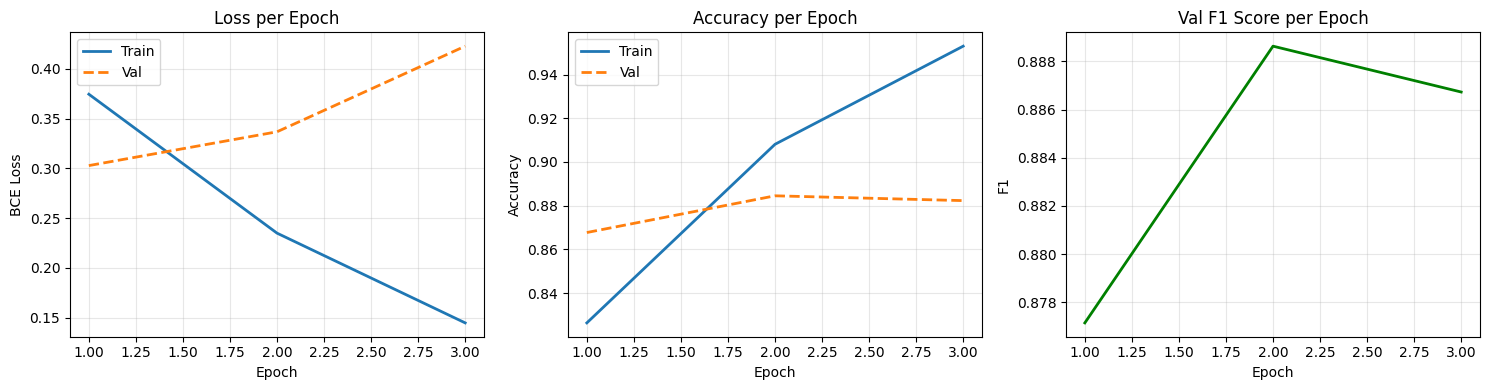

In [13]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history['val_f1'], color='green', linewidth=2)
axes[2].set_title('Val F1 Score per Epoch'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_distilbert.png', dpi=150)
plt.show()

---
## Step 11 — Final Test Evaluation

In [14]:
final_metrics, y_pred, y_true, y_probs = eval_epoch(model, test_loader, criterion)

print("── Final Test Metrics ─────────────────────────────")
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

print("\n── Classification Report ──────────────────────────")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

── Final Test Metrics ─────────────────────────────
  loss        : 0.3028
  accuracy    : 0.8677
  precision   : 0.8243
  recall      : 0.9373
  f1          : 0.8771

── Classification Report ──────────────────────────
              precision    recall  f1-score   support

    Negative       0.93      0.80      0.86      4961
    Positive       0.82      0.94      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



---
## Step 12 — Confusion Matrix

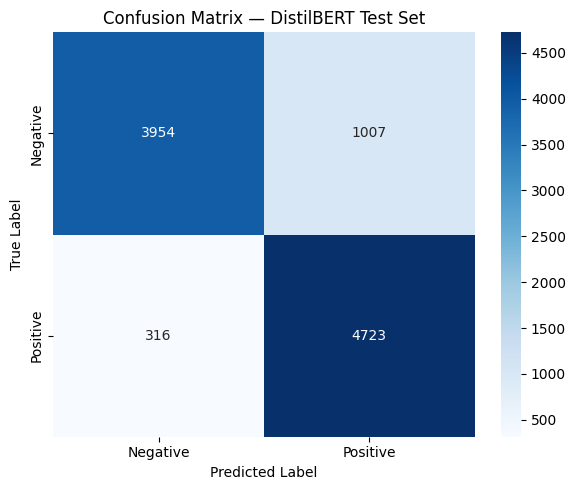

TN=3954  FP=1007  FN=316  TP=4723


In [15]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=ax
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — DistilBERT Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix_distilbert.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

---
## Step 13 — ROC Curve & AUC

Optimal decision threshold: 0.699
AUC: 0.9518


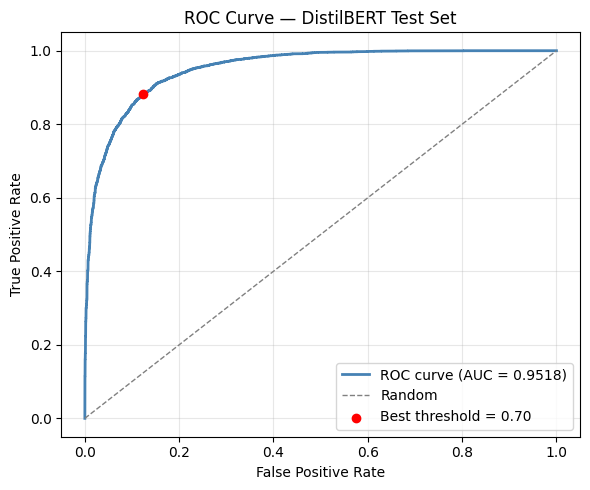

In [16]:
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

best_idx    = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]
print(f"Optimal decision threshold: {best_thresh:.3f}")
print(f"AUC: {roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
ax.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
           label=f'Best threshold = {best_thresh:.2f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — DistilBERT Test Set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_distilbert.png', dpi=150)
plt.show()

---
## Step 14 — Inference on Custom Text

In [17]:
def predict_sentiment(review_text: str, threshold: float = 0.5) -> dict:
    """
    Predict sentiment for a single raw review string using DistilBERT.
    """
    model.eval()
    encoding = tokenizer(
        review_text,
        max_length     = MAX_LEN,
        truncation     = True,
        padding        = 'max_length',
        return_tensors = 'pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        prob = model(input_ids, attention_mask).item()

    label = 'Positive' if prob >= threshold else 'Negative'
    conf  = prob if prob >= threshold else 1 - prob
    return {'label': label, 'probability': round(prob, 4), 'confidence': round(conf, 4)}


samples = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Waste of two hours. The plot made no sense at all.",
    "It was okay, nothing special but not bad either."
]

for text in samples:
    result = predict_sentiment(text)
    print(f"[{result['label']}] (p={result['probability']}, conf={result['confidence']})")
    print(f"  → {text[:70]}...\n")

[Positive] (p=0.9942, conf=0.9942)
  → This movie was absolutely fantastic! The acting was superb....

[Negative] (p=0.0044, conf=0.9956)
  → Terrible film. Waste of two hours. The plot made no sense at all....

[Positive] (p=0.5256, conf=0.5256)
  → It was okay, nothing special but not bad either....



---
## Step 15 — Save Model

In [18]:
torch.save(model.state_dict(), 'sentiment_model_distilbert.pt')
print("Model saved → sentiment_model_distilbert.pt")

# To reload later:
# loaded_model = SentimentDistilBERT().to(device)
# loaded_model.load_state_dict(torch.load('sentiment_model_distilbert.pt'))
# loaded_model.eval()

Model saved → sentiment_model_distilbert.pt
